# JN-M — Berkeley Corridor Housing Density

**Question (John's thesis):** College Ave / Elmwood has far more multi-unit housing per block than the
zoning label suggests, and people are *"building in their back yards"* — adding ADUs on lots the map
calls single-family. Show it, and compare College to other corridors and to the rest of Berkeley.

**Headline finding.** College–Elmwood (Dwight→Alcatraz) runs **~15 du/acre — 2.2× the citywide median
(6.8)** — and *exceeds* the University Ave commercial corridor (6.0). The **East side of College**
(zoned low "for fire evacuation") carries **~4× the ADU-building rate of the West** — densification is
concentrated on exactly the side the map freezes.

**Method, in one line:** existing stock = Census 2020 PL (units/pop per block) on TIGER2020 geometry;
adds = our fixed-classifier ADU cohort; corridors cut at the city's own boundaries (College = Dwight→
Alcatraz, per the Corridors Zoning Update). Density = units per **land** acre.

> **Current regime = Middle Housing (Ord. 7,978-N.S., effective Nov 1 2025):** up to **8 units by-right on
> a 5,000 sf residential lot** (≈70 du/ac), everywhere residential except the high fire-hazard hills. This
> supersedes the old R-1…R-4 du/ac caps — so this notebook benchmarks existing density against the **Middle
> Housing allowance**, not the defunct districts.

> **Discipline:** every number below is DERIVED and gated against an external timestamped baseline
> (`data/baselines/corridor_density_baseline_2026-08-12.json`). A legitimate change = append a new
> baseline, never edit a magic number.

## Data lineage

```mermaid
graph LR
  PL[Census 2020 PL 94-171<br/>pop P1 + housing H1] --> BLK[berkeley_blocks_2020.geojson<br/>1,522 blocks]
  TIG[TIGER2020 tabblock20<br/>geometry + ALAND] --> BLK
  ADU[ADU cohort<br/>fixed classifier, ~93% vs APR] --> IDX
  PAR[berkeley.db parcels<br/>situs -> corridor tag] --> IDX
  BLK --> IDX[block_density_index.py<br/>build + corridor_summary]
  CZU[CZU Existing Conditions<br/>Dwight->Alcatraz, zoned caps] -.corridor bounds + caps.-> IDX
  IDX --> FIG[figures -> baseline gate]
  IDX --> VIZ[choropleth / 3D KML / vs-zoned]
```

**Not a data source (firewall):** the HCD APR (validation oracle only) and the CZU's *derived* density
numbers (comparison target only). Per-parcel **zoning** is form-based and lives behind Accela ACA (to be
harvested there — Socrata WAF-blocks this environment); it is NOT ingested here.

In [1]:
import os, sys, json
# resolve repo root (dir with CLAUDE.md) so relative data paths + the scripts import work from anywhere
_d = os.getcwd()
while _d != "/" and not os.path.exists(os.path.join(_d, "CLAUDE.md")): _d = os.path.dirname(_d)
os.chdir(_d); sys.path.insert(0, os.path.join(_d, "scripts"))
from block_density_index import build, corridor_summary, figures
import pandas as pd; pd.set_option("display.width", 170)
blk = build()
summary = corridor_summary(blk)
summary

,cohort,blocks,acres,units,du_per_ac,ppl_per_ac,adu_adds,adu_per_ac,pct_of_mh
0,College (Elmwood),44,195.5,2959,15.14,30.71,62,0.317,21.7
1,Telegraph,31,110.4,1847,16.74,39.74,15,0.136,NaN
2,Adeline,20,62.0,708,11.43,27.93,4,0.065,16.4
3,University,46,479.5,2899,6.05,11.50,5,0.010,NaN
4,Solano,11,53.0,308,5.82,12.63,8,0.151,8.3
5,College West,20,82.8,1510,18.24,36.99,12,0.145,NaN
6,College East,24,112.7,1449,12.86,26.10,50,0.444,NaN
7,Rest of Berkeley,1370,5753.8,43557,7.57,18.40,780,0.136,NaN
8,ALL Berkeley,1522,6654.1,52278,7.86,18.66,874,0.131,NaN


### Reading the table
`du_per_ac` = existing housing units per **land** acre (Census 2020). `adu_per_ac` = our ADU cohort
adds per acre — the *backyard-building rate*. `pct_of_cap` = existing density as a share of the
**indicative** zoned du/ac cap (only meaningful for the lot-area-per-unit zones — R-1/R-2/R-2A; the
`NaN` corridors are form-based, no du/ac cap). The two indented rows split College **East vs West** of
the avenue centerline.

## The Elmwood District vs non-student Berkeley (official neighborhood boundary)

Using the city's own **Elmwood District** neighborhood polygon (from the Berkeley ArcGIS org — not a
hand-drawn box, which diluted an earlier pass to 7.8), the **district-wide** claim holds: Elmwood is
**~1.85× denser than non-student Berkeley** (12.8 vs 6.9 du/ac), with a clear majority of its blocks above
the non-student median. And the commercial strip the CZU height change targets is a **5.3-acre BID** — against
a 376-acre residential neighborhood. **The argument:** strengthen the century-old *residential* densification
(multi-unit apartments, single-family→rental conversions, ADUs, Middle Housing), don't rezone 5.3 acres.
*(Honest bound: "every block denser than everywhere" is NOT supported — ~69%, a supermajority, not all.)*

In [2]:
from block_density_index import elmwood_district_mask, nonstudent_mask, bid_commercial_acres
ed = elmwood_district_mask(blk); ns = nonstudent_mask(blk)
d_el = blk[ed].housing_units.sum()/blk[ed].acres.sum(); d_ns = blk[ns].housing_units.sum()/blk[ns].acres.sum()
print(f"Elmwood District:      {int(ed.sum())} blocks, {blk[ed].acres.sum():.0f} ac, {d_el:.1f} du/ac")
print(f"Non-student Berkeley:  {d_ns:.1f} du/ac   ->   Elmwood = {d_el/d_ns:.2f}x")
print(f"Elmwood blocks above the non-student median ({blk[ns].dua.median():.1f}): {(blk[ed].dua>blk[ns].dua.median()).mean()*100:.0f}%")
print(f"Elmwood commercial BID (the CZU height-change target): {bid_commercial_acres()} acres "
      f"vs the {blk[ed].acres.sum():.0f}-acre residential neighborhood")

Elmwood District:      93 blocks, 377 ac, 12.8 du/ac
Non-student Berkeley:  6.9 du/ac   ->   Elmwood = 1.84x
Elmwood blocks above the non-student median (6.4): 69%
Elmwood commercial BID (the CZU height-change target): 5.3 acres vs the 377-acre residential neighborhood


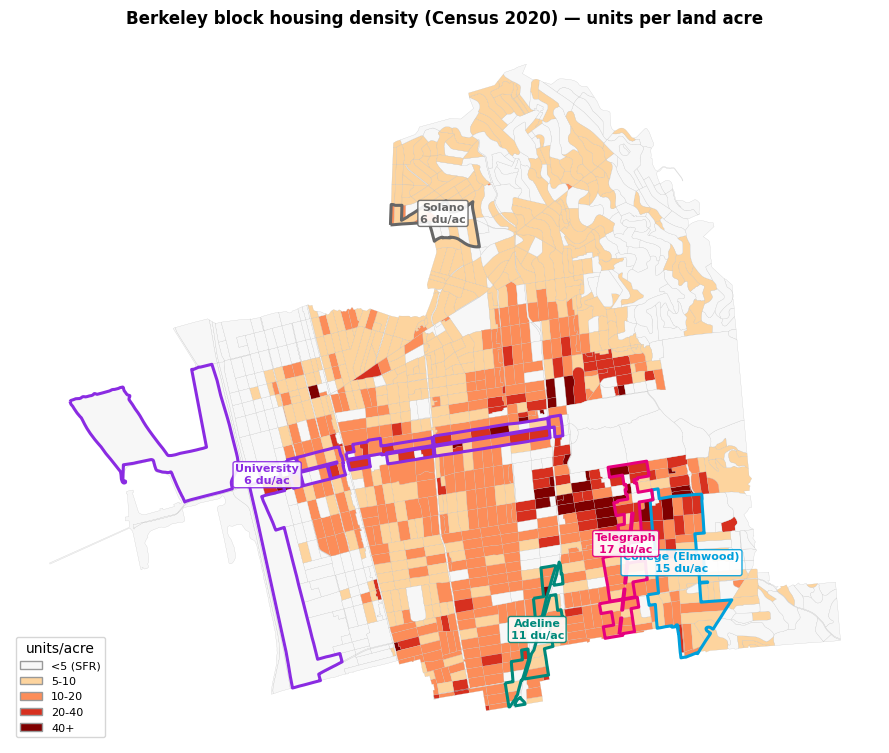

In [3]:
# --- VIZ 1: choropleth (where) — blocks colored by du/acre, corridors outlined ---
import matplotlib.pyplot as plt, numpy as np
from matplotlib.colors import ListedColormap; from matplotlib.patches import Patch
g = blk.to_crs(3857)
bins=[0,5,10,20,40,1e9]; cols=["#f7f7f7","#fdd49e","#fc8d59","#d7301f","#7f0000"]
g["cls"]=pd.cut(g.dua,bins=bins,labels=False,include_lowest=True)
fig,ax=plt.subplots(figsize=(9,11))
g.plot(ax=ax,color=[cols[int(c)] if pd.notna(c) else "#eee" for c in g.cls],edgecolor="#bbb",linewidth=.15)
CC={"College (Elmwood)":"#00a0dc","University":"#8a2be2","Adeline":"#00897b","Telegraph":"#e6007e","Solano":"#666"}
for n,c in CC.items():
    s=g[g.corridor==n]
    if len(s):
        s.dissolve().boundary.plot(ax=ax,edgecolor=c,linewidth=2.2)
        cx,cy=s.dissolve().geometry.centroid.iloc[0].coords[0]
        ax.annotate(f"{n}\n{s.housing_units.sum()/s.acres.sum():.0f} du/ac",(cx,cy),ha="center",
                    fontsize=8,fontweight="bold",color=c,bbox=dict(boxstyle="round,pad=.2",fc="white",ec=c,alpha=.9))
ax.legend(handles=[Patch(fc=cols[i],ec="#999",label=l) for i,l in enumerate(["<5 (SFR)","5-10","10-20","20-40","40+"])],
          loc="lower left",fontsize=8,title="units/acre")
ax.set_title("Berkeley block housing density (Census 2020) — units per land acre",fontweight="bold"); ax.set_axis_off()
plt.tight_layout(); plt.show()

> **What this could mislead about:** hills read white (low) partly because blocks are large — always
> pair the map with the per-acre table. Corridor outlines are census blocks *near* the avenue, not
> parcel-exact frontage.

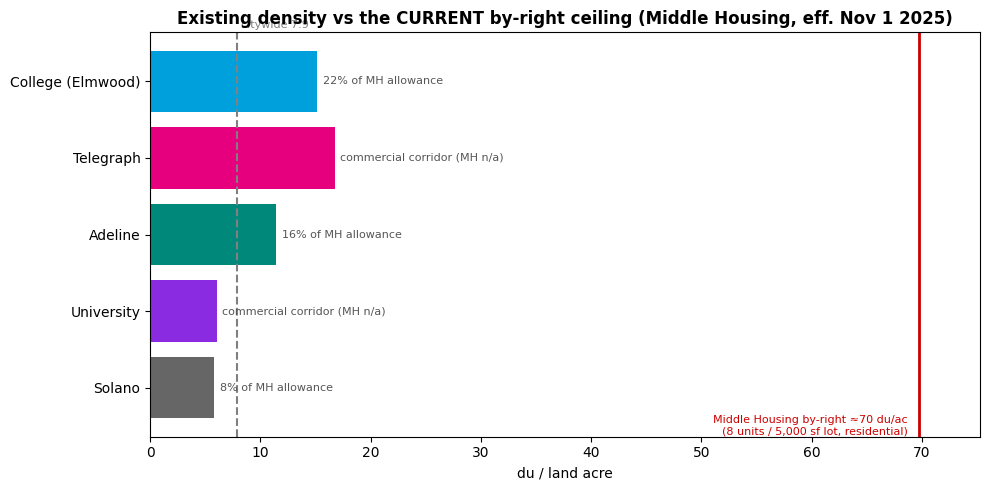

In [4]:
# --- VIZ 2: existing density vs the CURRENT by-right allowance (Middle Housing, eff Nov 1 2025) ---
from block_density_index import MH_BYRIGHT_DU_AC, MH_RESIDENTIAL
s=corridor_summary(blk).set_index("cohort")
order=["College (Elmwood)","Telegraph","Adeline","University","Solano"]
dua=[float(s.loc[c,"du_per_ac"]) for c in order]; city=float(blk.housing_units.sum()/blk.acres.sum())
fig,ax=plt.subplots(figsize=(10,5)); y=np.arange(len(order))
ax.barh(y,dua,color=["#00a0dc","#e6007e","#00897b","#8a2be2","#666"])
ax.axvline(MH_BYRIGHT_DU_AC,color="#c00",lw=2)
ax.text(MH_BYRIGHT_DU_AC-1,len(order)-0.5,f"Middle Housing by-right ≈{MH_BYRIGHT_DU_AC:.0f} du/ac\n(8 units / 5,000 sf lot, residential)",
        ha="right",va="center",fontsize=8,color="#c00")
ax.axvline(city,ls="--",color="gray"); ax.text(city+.4,-.7,f"citywide {city:.1f}",fontsize=8,color="gray")
for i,c in enumerate(order):
    tag = f"{100*dua[i]/MH_BYRIGHT_DU_AC:.0f}% of MH allowance" if c in MH_RESIDENTIAL else "commercial corridor (MH n/a)"
    ax.text(dua[i]+.5,i,tag,va="center",fontsize=8,color="#555")
ax.set_yticks(y); ax.set_yticklabels(order); ax.invert_yaxis(); ax.set_xlabel("du / land acre")
ax.set_xlim(0, MH_BYRIGHT_DU_AC*1.08)
ax.set_title("Existing density vs the CURRENT by-right ceiling (Middle Housing, eff. Nov 1 2025)",fontweight="bold")
plt.tight_layout(); plt.show()

## Reframe: the current regime is Middle Housing, not the old districts

The **Middle Housing Ordinance (7,978-N.S., effective Nov 1 2025)** allows **up to 8 units by-right on a
typical 5,000 sf residential lot** (3 stories / 35 ft; ≈52 ft with density bonus) across **all primarily-
residential Berkeley EXCEPT the high fire-hazard hills.** That **supersedes** the old R-1/R-2/R-2A/R-3/R-4
du/ac caps — so benchmarking existing density against those old caps is meaningless. The honest story:

- **The existing-density finding stands and is regime-independent** — College–Elmwood ~15 du/ac = 2.2×
  citywide is the *already-built* hidden multi-unit + backyard-ADU density, whatever the code says.
- **Against the current ~70 du/ac by-right ceiling, every corridor is far below** — College–Elmwood is
  only ~**22%** of what Middle Housing now permits. The story flips from "denser than allowed" to
  **"already dense, and now vastly more is legal by-right."**
- **The relevant map is now Middle-Housing-eligible vs fire-hazard-EXEMPT** (§2 below), not old districts.
  ADU-building is the one lever that still works in the exempt hill areas — worth testing whether the
  East-of-College ADU cluster sits inside the exemption.

**Per-parcel zoning / MH-eligibility** is **harvested via Accela ACA** (`aca-prod.accela.com/BERKELEY/`),
NOT Socrata (which WAF-blocks this environment). Queued.

## §2 — Middle-Housing-eligible vs fire-hazard-EXEMPT

Middle Housing exempts the high fire-hazard hills. So the current-regime map is **eligible vs exempt**, not
old districts. Overlaying Berkeley's Hill/Fire Zones (city ArcGIS org, curl-accessible — *not* Socrata) on
the corridor blocks tests a tempting hypothesis: *is the ADU-heavy East side of College inside the fire
exemption (i.e., the one lever left where MH doesn't reach)?*

In [5]:
# --- fire-hazard (MH-exempt) overlay: Hill Zone 2-3 ---
from block_density_index import fire_exempt_mask
b = blk.copy(); b["fire_exempt"] = fire_exempt_mask(b)
print(f"Berkeley blocks in high-fire-hazard (Hill Zone 2-3, MH-exempt): {int(b.fire_exempt.sum())} / {len(b)}")
ce = b[b.corridor == "College (Elmwood)"]
for side in ["West", "East"]:
    s = ce[ce.college_side == side]
    print(f"  College {side:5}: {len(s):2} blocks | in fire-exempt zone = {int(s.fire_exempt.sum())} | "
          f"ADUs = {int(s.adu_adds.sum())} | {s.housing_units.sum()/s.acres.sum():.1f} du/ac")

Berkeley blocks in high-fire-hazard (Hill Zone 2-3, MH-exempt): 364 / 1522
  College West : 20 blocks | in fire-exempt zone = 0 | ADUs = 12 | 18.2 du/ac
  College East : 24 blocks | in fire-exempt zone = 0 | ADUs = 50 | 12.9 du/ac


**Result — hypothesis disproved.** College–Elmwood is **0 / 44 blocks** in the fire-hazard zone (it's
flatland) — **both sides are fully MH-eligible.** So the ~4× ADU concentration on the East side is **not** a
fire-exemption artifact; its cause is elsewhere (larger single-family lots / owner-builder incentive — to
test next). The density corridors all sit **outside** the ~24% of the city (the hills) that MH exempts —
i.e., Middle Housing's 8-units-by-right *does* reach exactly where the hidden density already is.

In [6]:
# --- BASELINE GATE: derive vs the external timestamped baseline (never hardcode) ---
base=json.load(open("data/baselines/corridor_density_baseline_2026-08-12_mh.json"))
got=figures(blk); want=base["figures"]; bad={}
for k,v in want.items():
    if k in got and abs(float(got[k])-float(v))>0.05: bad[k]=(got[k],v)   # ghost figures are gated in §3
if bad:
    raise AssertionError(f"figures drifted vs baseline {base['created']} @ {base['git_sha']}: {bad}\n"
                         "-> DIAGNOSE (computed vs baseline, likely cause) then APPEND a new timestamped baseline, do not edit magic numbers.")
print(f"baseline gate PASS — {len(want)} figures match {base['created']} @ {base['git_sha']}")
print(json.dumps(got,indent=2))

baseline gate PASS — 24 figures match 2026-08-12 @ 240c374
{
  "berkeley_blocks_fire_exempt": 364,
  "college_elmwood_blocks_fire_exempt": 0,
  "n_blocks": 1522,
  "total_housing_units": 52278,
  "total_pop": 124197,
  "citywide_du_per_ac": 7.86,
  "citywide_median_block_dua": 6.85,
  "college_elmwood_du_per_ac": 15.14,
  "college_west_du_per_ac": 18.24,
  "college_east_du_per_ac": 12.86,
  "college_elmwood_adu_adds": 62,
  "college_east_adu_adds": 50,
  "college_west_adu_adds": 12,
  "mh_byright_du_per_ac": 69.7,
  "college_elmwood_pct_of_mh": 21.7,
  "elmwood_district_du_per_ac": 12.8,
  "nonstudent_du_per_ac": 6.9,
  "elmwood_pct_blocks_above_nonstudent_median": 69,
  "elmwood_bid_commercial_acres": 5.3
}


## §3 — Ghost units: what the assessor and the zoning map under-record

The city assigns an official **address** to a dwelling unit even when it was never permitted or licensed. So
Berkeley's RPP address layer carries **secondary-unit addresses** (½ / A-B / rear / cottage) — a signal of
units-on-the-ground. Cross-referenced against the assessor (restricted to low-density-residential parcels, so
**condos/apartments are structurally excluded** — they're assessed, not hidden):

- **Elmwood: 53 parcels the assessor calls single-family/duplex carry a secondary-unit address it doesn't count**
  (assessor-undercount), + 163 where the assessor *does* count the extra unit (assessed-multiunit, e.g. 2811½
  Benvenue — a real unpermitted cottage the assessor records as unit 2).
- Citywide: 444 assessor-undercount + 1,783 assessed-multiunit.

> **Counting rule (load-bearing):** this is a **DISCREPANCY** signal — *where the parcel/zoning data under-records
> reality* — **NOT additive to the block housing-unit totals.** Existing units per block stay anchored on the
> **Census** (`HOUSING20`), which counts condos and most units already. Ghost units show that the "single-family"
> label is wrong on the ground; they are **candidates** (a letter suffix is a strong-but-imperfect unit proxy)
> pending ground-truth. Never sum them onto Census.

In [7]:
from ghost_units import build_ghost, ghost_figures
gP = build_ghost(); gfig = ghost_figures(gP)
import json; print(json.dumps(gfig, indent=2))
# baseline gate for the ghost figures (derive vs baseline, never hardcode)
_b = json.load(open("data/baselines/corridor_density_baseline_2026-08-12_mh.json"))["figures"]
_bad = {k: (gfig[k], _b[k]) for k in gfig if abs(gfig[k]-_b[k]) > 0}
assert not _bad, f"ghost figures drifted vs baseline: {_bad} -> diagnose then append a new baseline"
print("ghost baseline gate PASS")

{
  "elmwood_ghost_parcels": 216,
  "elmwood_assessor_undercount": 53,
  "elmwood_assessed_multiunit": 163,
  "citywide_assessor_undercount": 444,
  "citywide_assessed_multiunit": 1783
}
ghost baseline gate PASS


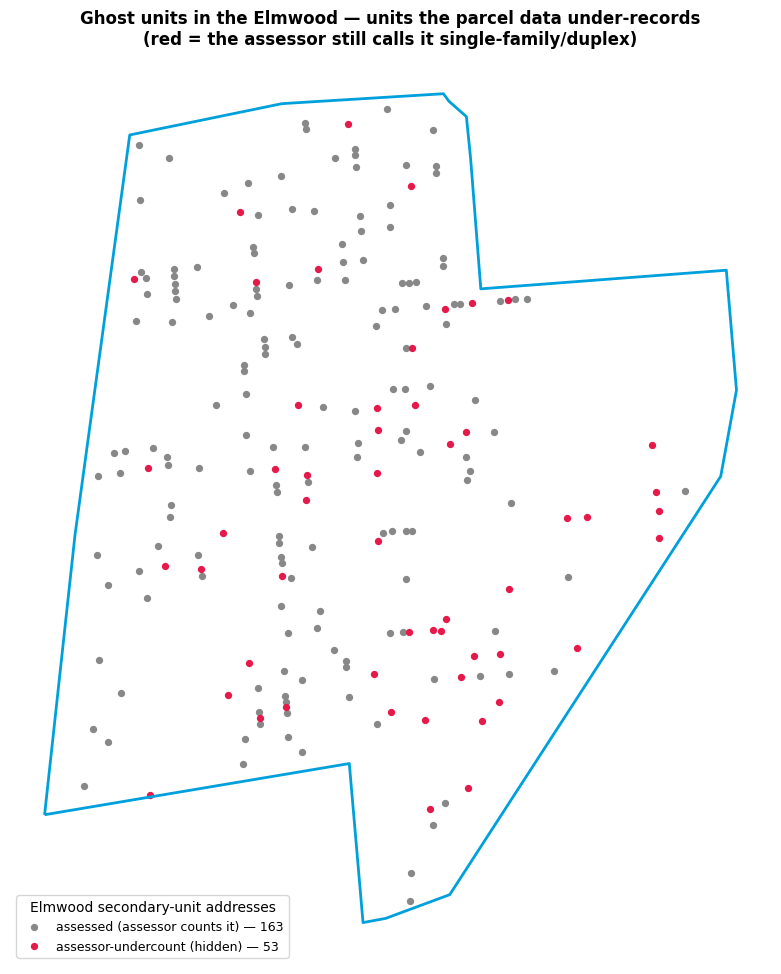

In [8]:
# --- VIZ 3: the reveal — Elmwood 'single-family/duplex' parcels that carry a hidden secondary-unit address ---
import matplotlib.pyplot as plt, geopandas as gpd
elg = gP[gP.elmwood].to_crs(3857)
nb = gpd.read_file("data/reference/berkeley_neighborhoods.geojson").to_crs(3857)
elb = nb[nb.Name.astype(str).str.contains("lmwood", case=False)]
fig, ax = plt.subplots(figsize=(9, 10))
elb.boundary.plot(ax=ax, edgecolor="#00a0dc", linewidth=2)
for cls, col, lbl in [("assessed_multiunit", "#888", "assessed (assessor counts it)"),
                      ("assessor_undercount", "#e6194b", "assessor-undercount (hidden)")]:
    s = elg[elg.cls == cls]
    s.plot(ax=ax, color=col, markersize=18, label=f"{lbl} — {len(s)}")
ax.legend(loc="lower left", fontsize=9, title="Elmwood secondary-unit addresses")
ax.set_title("Ghost units in the Elmwood — units the parcel data under-records\n(red = the assessor still calls it single-family/duplex)", fontweight="bold")
ax.set_axis_off(); plt.tight_layout(); plt.show()

> **What this could mislead about:** each dot is an *address*, not a certified unit — some letter suffixes are
> legal multi-unit buildings on a duplex-coded parcel (e.g. `2723 Ashby A-D`). The **red (assessor-undercount)**
> class is the sharpest signal; ground-truthing a sample sets the false-positive rate. And, again: this maps the
> *discrepancy*, not additional units to add to the Census block totals.

## ⚠️ Measuring recent densification — YearBuilt is the wrong noun (definitional guardrail)

The existing-density finding above is **regime-independent and robust** (it's built stock). But do **NOT**
measure *recent* housing from the assessor's **YearBuilt**: an **ADU adds a dwelling unit without changing
the building's year built**, so YearBuilt counts new *structures*, not new *units*, and is structurally blind
to the backyard densification that is the Elmwood story. (An early pass mis-read "3 units since 1995" as
"frozen" — that was a definitional error; it measured new buildings, not new units.)

**Proof — 2811 / 2822 Benvenue:** two ADUs built, a rental license held, an RHSP inspection + paid fee — and
**six datasets miss all of it**: assessor YearBuilt (blind), assessor Units (2822 reads 1), business licenses
(13,004 records, absent), our 2018+ ADU cohort (absent), v4 permit events (absent), Rent Board rent_control
(absent). The city holds every record; they live in **Accela ACA**, the only complete source.

**The correct temporal metric is `permitted_units_added`** — the ADU/new-dwelling *building-permit* event
harvested from Accela (`aca-prod.accela.com/BERKELEY/`), never YearBuilt. Pilot scoped against the Benvenue
block (`notes/2026-08-12_accela_benvenue_adu_harvest_scope.md`); it validates only if 2811 & 2822 light up.

## Next steps (queued)
1. **Accela ACA per-parcel zoning harvest** for the corridor parcels → parcel-exact "denser than
   zoned" (our HARVESTER; John logs in). Replaces the WAF-dead Socrata path.
2. **CPRA #26-1972-style request** already drafted (`notes/2026-08-12_cpra_corridors_parcel_gis.md`)
   for Raimi's parcel GIS (existing units + opportunity coding) as an independent cross-check.
3. **Building footprints / sqft** → realized FAR → the FAR-headroom version for form-based zones.
4. **deck.gl / 3D KML** density skyline for the web (the extruded-block KML is built).